In [2]:
# Standard libraries
import warnings
from typing import Tuple, List, Union, Any

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.axes

# Model persistence
import joblib

# Preprocessing & pipelines
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Model inspection & interpretability
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.inspection import partial_dependence, permutation_importance
from lime.lime_tabular import LimeTabularExplainer
!pip install --quiet alibi
from alibi.explainers import AnchorTabular
import shap
from model import WhiteBox

# Warnings
from sklearn.exceptions import InconsistentVersionWarning
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Imbalanced-learn ---
# pipeline with samplers
from imblearn.pipeline import Pipeline as ImbPipeline   
# base class for SMOTE/ADASYN/etc.
from imblearn.base import BaseSampler                   
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Initialize SHAP visualizations
shap.initjs()


# **It's Jaundice's World, and St. James Hospital is Just Living in It.**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

# **I. Executive Summary**

Data Monitors developed a machine learning model for St. James Hospital’s OB-GYN facility to classify newborns as either at-risk or healthy. Thirteen weeks after deployment, a newborn was misclassified as healthy and died, with similar cases later uncovered being misclassified as healthy. The incident eroded trust in the system and triggered an independent audit. We take  this case with three goals: to improve the monitoring process of St. James Hospital OB-GYN department; to provide a framework for improving model reliability and interpretability with a proof-of-concept model; and to define clear AI accountability and governance.

Our analysis revealed several key areas for improvement in both the hospital process and the model. First, we found that the OB-GYN data could be better integrated into the overall hospital system by using a patient ID instead of a baby ID, ensuring continuity and consistency in medical records. Second, we observed that staff were over-relying on the automated system, highlighting the need for stronger human oversight to ensure that clinical expertise remains central in decision-making. 

On the model side, our explainability analysis showed that it relied too heavily on jaundice levels when predicting a baby’s health risk. Using global explainability tools such as SHAP values, permutation importance, and model coefficients, we found that jaundice consistently ranked far above every other feature. Feature interaction analysis with Friedman’s H-statistic further indicated weak dependencies between jaundice and other variables. It was only about 42% with oxygen saturation and 34% with heart rate. Local explainability methods allowed us to dig deeper and identify the concrete rules the model applies. Using Anchors, we found that the most common rule was that if a baby’s jaundice level is below 4.30 mg/dL, the model always predicts the baby as healthy, regardless of other feature values. LIME further illustrated that two otherwise similar babies could be classified differently solely based on their jaundice levels. Together, these analyses show that while jaundice is a valid indicator of health, overreliance on it creates blind spots that are dangerous in practice.

To address these issues, we propose three methodologies to prevent similar failures in the future. First, we aim to improve St. James Hospital’s monitoring process by emphasizing better integration of hospital records and maintaining human oversight even with automated systems. Second, we describe a practical model development process that focuses on preprocessing, assessing class imbalance, experimenting with resampling strategies if necessary, and evaluating which features require standardization. Our white-box proof-of-concept model achieved over 99% F1-score for at-risk babies while distributing feature importance more evenly. Third, we implement a transparent AI Accountability and Governance Framework to define clear roles, responsibilities, and liability between St. James Hospital and Data Monitors. This framework establishes decision-making authority, outlines responsibility for data quality, model monitoring, and clinical interpretation, and provides a clear process for fault assessment and liability assignment should future failures occur.


(The project environment is set up with Python version 3.12.8.)

---

# **II. Introduction** 

Data Monitors deployed a machine learning model at St. James Hospital’s OB-GYN facility to classify newborns as healthy or at-risk, aiming to reduce the monitoring burden on staff. However, in its thirtieth week, the system misclassified an at-risk newborn as healthy, resulting in the infant’s death. A review revealed other misclassifications, undermining trust in the algorithm. This raises the challenge of understanding why the current monitoring process failed.

To address this issue, we propose three methodologies that will follow the objectives set below:

1. **Monitoring Process Improvement:** To analyze the current St. James Hospital monitoring processes and design solutions that integrate robust human oversight into the automated neonatal monitoring workflow.  
2. **Model Development Enhancement:** To dissect the model's failure and develop a stronger, more reliable model development framework for Data Monitors centered on interpretability and performance in high-stakes medical decision-making.  
3. **AI Accountability and Governance Framework:** To establish a comprehensive AI accountability and governance framework that clearly defines roles, responsibilities, and liability between the hospital and the technology vendor.  

Based on these objectives, we ask the following key questions:

### Improvements on the Monitoring Process of St. James Hospital
- How can we improve data interoperability between the OB-GYN department and the overall hospital to ensure comprehensive patient records?  
- How can we establish and empower the human-in-the-loop process, ensuring medical experts are always available to verify and override the model’s classification when necessary?  

### Strengthening Model-Making of Data Monitors

**Feature Analysis**  
- Which features primarily influenced the model’s predictions for healthy versus at-risk babies?  

**Model Improvement**  
- Which metrics are most appropriate for the objective of the OB-GYN facility? Should strategies such as class balancing or feature engineering be applied?  
- Does the redesigned model correctly classify the previously misclassified babies, and how does it perform overall on both healthy and at-risk populations?  

### Proposal of an AI Accountability and Governance Framework
- What specific roles and responsibilities must be assigned to St. James Hospital (e.g., data input quality, clinical validation) versus Data Monitors (e.g., model maintenance, drift detection)?  
- How will the system define fault when a misclassification occurs (i.e., when is the error attributable to model failure, data degradation, or human process violation)?  
- What are the mandatory monitoring requirements (frequency, metrics, access) the hospital must enforce upon the vendor to ensure continuous compliance and performance?



# **III. Improvements on the Monitoring Process of St. James Hospital** 

In trying to improve the processes of St. James Hospital, the interoperability of data between departments can be better improved. For example, the use of a unique ```baby_id``` in the CSV files suggests that data from the OB-GYN department is siloed and not fully integrated with the hospital’s main patient information system. This separation limits data continuity once the newborn leaves the department, making it difficult to track long-term outcomes or cross-reference with other medical visits. To address this, we recommend adopting a unified patient ID system across all hospital departments. This system would allow each newborn’s medical record to evolve into a lifelong patient history, improving coordination between pediatric, general, and specialty care while supporting future data analytics on patient outcomes.

Second, the hospital’s monitoring process needs reassessment. The system’s success led staff to “not monitor the babies that actively anymore,” signaling overreliance on automation. This poses both ethical and regulatory risks since Article 22 of the EU GDPR prohibits fully automated decision-making that significantly affects individuals without meaningful human oversight. In healthcare, this undermines the principle that AI should augment, not replace, clinical judgment. Introducing structured human-in-the-loop checks and escalation protocols would restore accountability, ensuring that automation enhances patient safety.

Based on the issues identified in the old process (Figure 1a), we propose a revised workflow to address them (Figure 1b). First, newborns will be registered using a hospital-wide patient ID instead of a department-specific ```baby_id```, ensuring continuity of medical records across departments. More importantly, the new process reinforces the role of medical staff in decision-making. Healthcare professionals will have the final authority to determine whether a baby is healthy or at-risk. They will be supported by model-generated insights where TreeExplainer will clarify why our model made a specific prediction while counterfactual explanations will guide staff in identifying actionable steps to improve an at-risk baby’s condition. We will give an example of a local explanation and a counterfactual in a later section of this report.


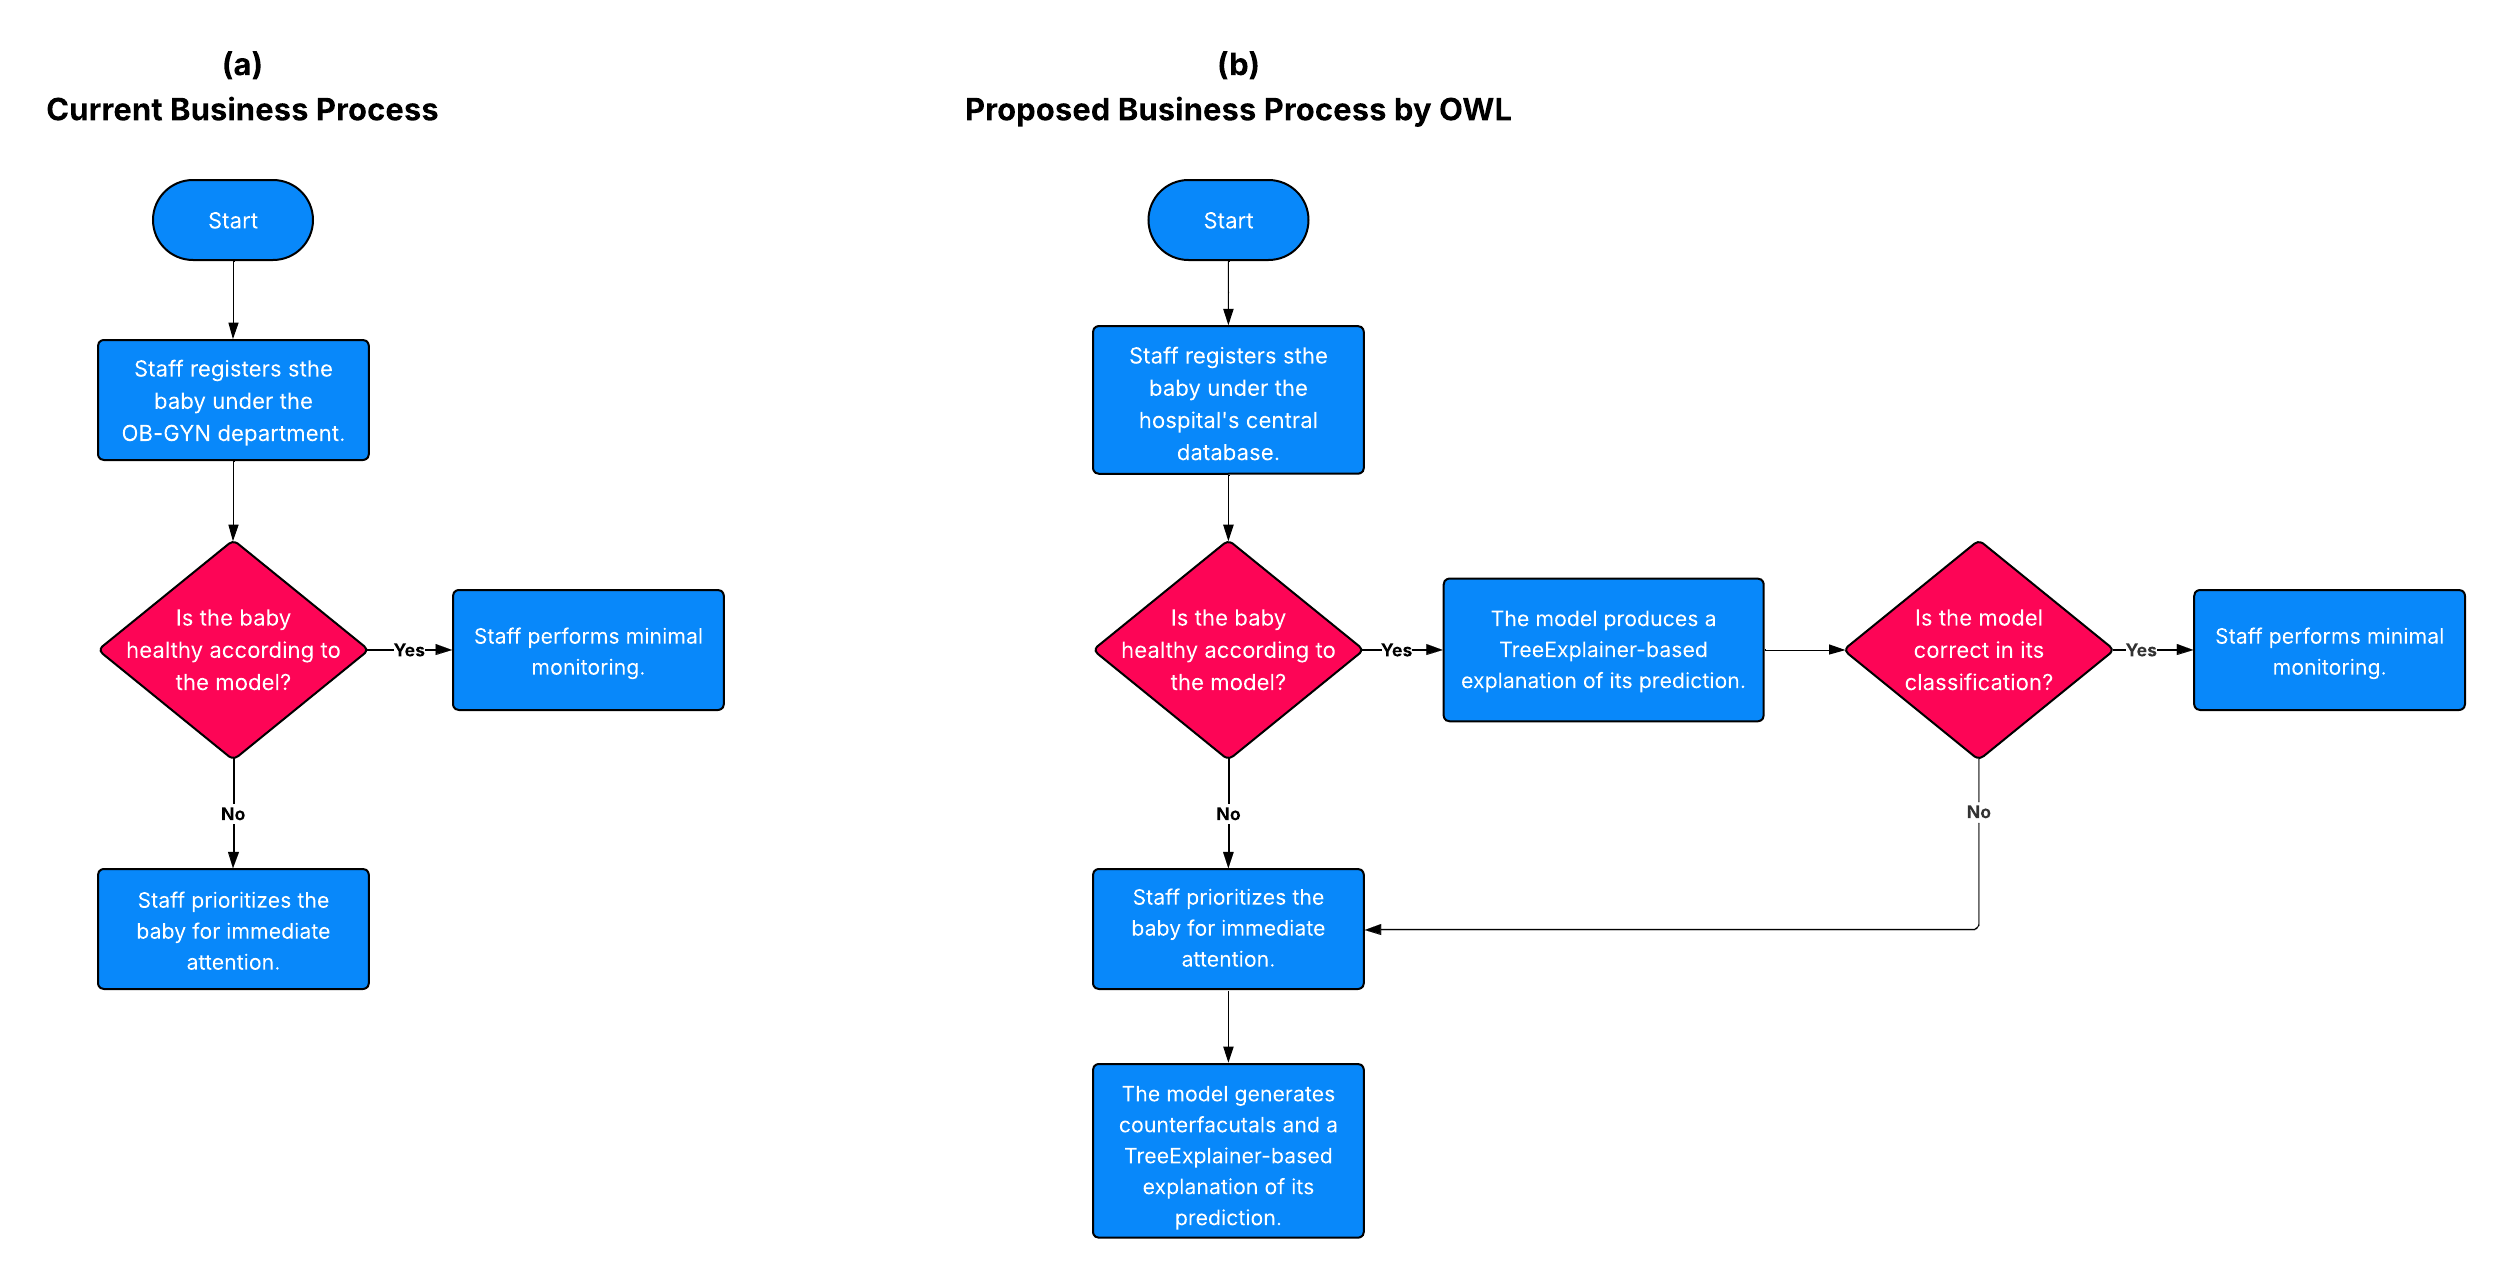
**Figure 1.** New (a) and Old (b) Monitoring Process



# **IV. Model-Making Improvement for Data Monitors**

As an overview, we provide a high-level summary in Figure 2 because this section will be the longest and most in-depth.

![Methodology](figures/02_methodology.png)
**Figure 2.** Overview of the Steps for the Model-Making Improvement for Data Monitors

---


### **4.1 Determine Important Features using Global Model-Agnositic Methods**

As an overview, we used SHAP values, permutation feature importance, and Friedman’s H-statistic were utilized to identify which variables the model relied on most heavily when making predictions.

First, SHAP values were used to aggregate individual feature contributions and provide a visual summary of the model’s overall behavior as seen in Figure 3. This analysis revealed that jaundice level, followed by heart rate, were the most critical risk factors. Specifically, high jaundice values strongly pushed predictions toward 'At Risk,' while low oxygen saturation and low birth weight also contributed to higher risk. 

In [3]:
# Set many of the variables to be used
historical_df = pd.read_csv('data/historical.csv')
misclassified_df = pd.read_csv('data/corrected_false_negatives.csv')

# the model by data monitors as old_model
old_model = joblib.load("data/model.joblib")

In [4]:
# Get processor and classifier from pipeline
processor = old_model["preprocess"]
clf = old_model["clf"]

# Get just the features
feature_names = historical_df.columns[:-1]
X_hist = historical_df[feature_names]

# Get preprocessed X and its feature names
X_preprocessed = processor.transform(X_hist)
preprocessed_feature_names = list(processor.get_feature_names_out())

# Get X and only its features and y where its label encoded
X = historical_df[processor.feature_names_in_]
y = historical_df[historical_df.columns[-1]].map({"Healthy": 0, "At Risk": 1})
y_class = historical_df[historical_df.columns[-1]]
#y = historical_df[historical_df.columns[-1]]

# Get the misclassified babies and their indices
X_hist['orig_index'] = X_hist.index

X_misclassified = X_hist.merge(
    misclassified_df,
    on=['baby_id', 'name', 'gender', 'date'],
    how='inner'
)

# Get the misclassified babies' indices and drop the index column
misclassified_indices = X_misclassified['orig_index'].tolist()
X_misclassified.drop(columns=['orig_index'], inplace=True)
X_hist.drop(columns=['orig_index'], inplace=True)

  0%|          | 0/100 [00:00<?, ?it/s]

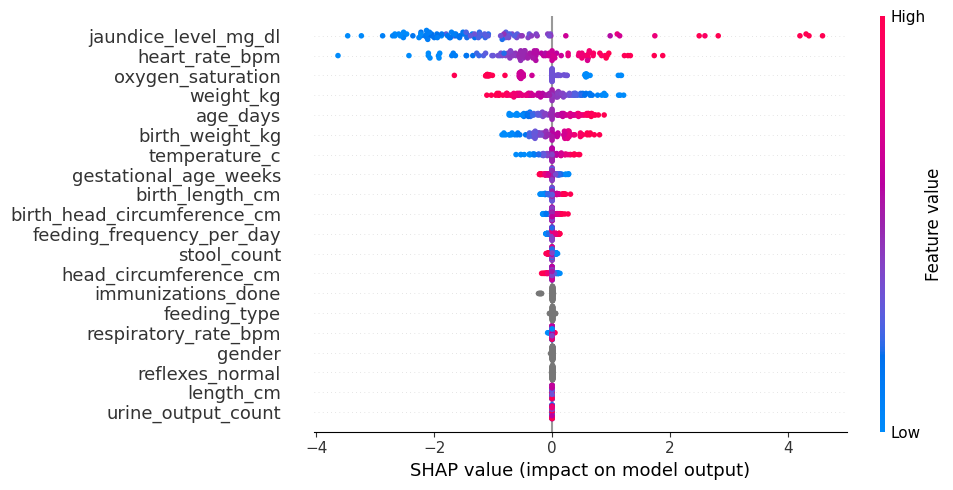

Figure 3. SHAP Summary: Key Drivers of At-Risk Predictions in Newborns


In [11]:
# Use the same X from permutation importance (raw features)
X_for_shap = X.copy()

# Wrap model function to keep DataFrame structure
model_fn = lambda x: old_model.predict_proba(
    pd.DataFrame(x, columns=X_for_shap.columns)
)

# Create KernelExplainer
shap_explainer = shap.KernelExplainer(
    model=model_fn,
    data=shap.sample(X_for_shap, 100, random_state=42),
    feature_names=X_for_shap.columns,
    link="logit"  # since we're predicting probabilities
)

# Compute SHAP values (on a sample for speed)
X_sample = shap.sample(X_for_shap, 100, random_state=42)
shap_values = shap_explainer.shap_values(X_sample)

# Select the class index you want to explain (1 = "At Risk")
class_idx = 1

# Summary plot 
plt.figure(figsize=(10, 5))
shap.summary_plot(
    shap_values[:, :, class_idx],
    X_sample,
    plot_size=(10, 5),
    show=False
)
# Save the image
fig_count = 3
image_path = f'figures/0{fig_count}_SHAP_old_model.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f'\033[1mFigure {fig_count}\033[0m. '
      "SHAP Summary: Key Drivers of At-Risk Predictions "
      "in Newborns for Data Monitors' Model"
)

fig_count += 1 

This result makes sense when we look at the histograms of Figure 4 where babies at-risk are more likely to have a high level of jaundice. This is also medically meaningful because elevated bilirubin levels, which cause jaundice, can indicate liver immaturity or hemolytic disorders in newborns, both of which increase the risk of complications if not managed promptly [1]. 

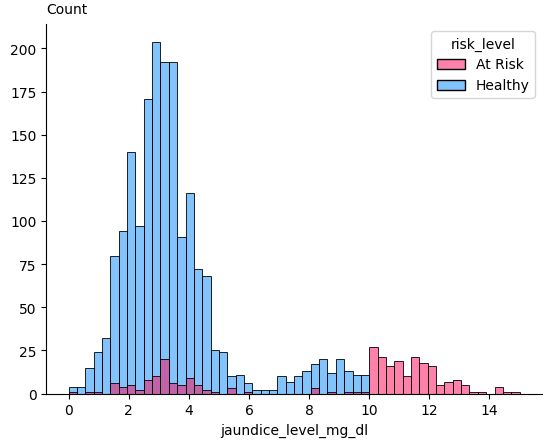

Figure 4. Distribution of Jaundice Levels by Risk Level


In [12]:
sns.histplot(
    data=historical_df,
    x='jaundice_level_mg_dl',
    hue='risk_level',
    palette={'Healthy': '#0888fa', 'At Risk': '#fd0556'},  # specify colors

);

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().yaxis.set_label_coords(0, 1.02)
plt.ylabel('Count', rotation=0, ha='left')
image_path = f'figures/0{fig_count}_histogram_jaundice.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f'\033[1mFigure {fig_count}\033[0m. Distribution of Jaundice Levels by Risk Level')
fig_count += 1 


Although it makes sense to have jaundice as an important feature because of the clear dividing line it has in Figure 4, further analysis indicated that the model was overreliant on this specific variable. We used permutation importance to quantify how much each feature affects the model's performance. Given the medical context, recall is a crucial metric because it directly measures the ability of the model to avoid false negatives. Because the babies’ lives are at-risk, we prioritized in making sure that a baby is not accidentally classified as healthy even though they are actually at-risk. As seen in Figure 5, the level of jaundice caused an approximate 50% drop in recall when shuffled, whereas other features had much smaller effects. 

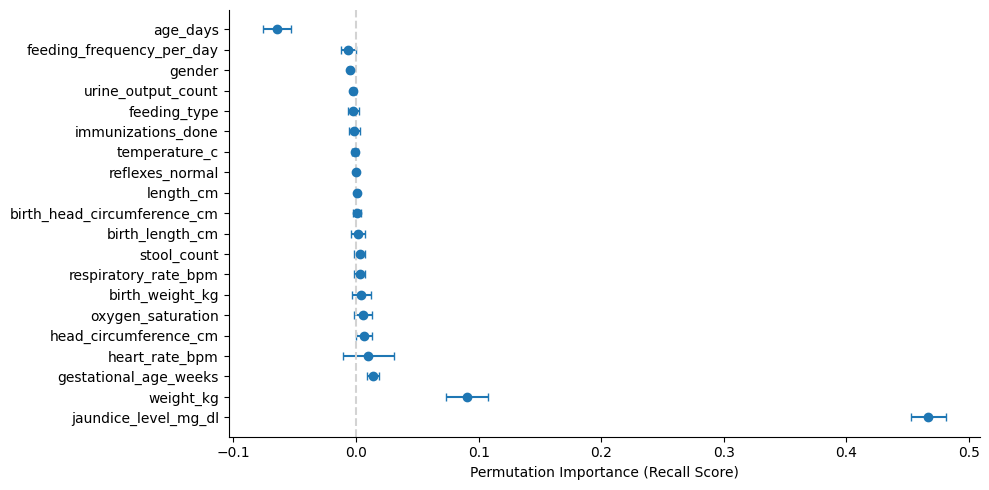

Figure 5. Permutation Importance of Features from Data Monitors


In [13]:
# Compute permutation importance on the pipeline
perm_imp = permutation_importance(
    old_model,
    X,
    y,
    scoring="recall",
    random_state=42,
    n_repeats=5
)

# Use raw column names (not preprocessed ones) for interpretability
FEATURE_NAMES = np.array(X.columns)

# Sort by importance
idx_order = np.argsort(-perm_imp.importances_mean)
ordered_means = perm_imp.importances_mean[idx_order]
ordered_stds = perm_imp.importances_std[idx_order]
ordered_labels = FEATURE_NAMES[idx_order]

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=ordered_means,
    y=ordered_labels,
    xerr=ordered_stds,
    fmt="o",
    capsize=3
)
plt.xlabel("Permutation Importance (Recall Score)")
plt.axvline(0, linestyle="--", c="lightgray")
#plt.title("Permutation Importance (Using Model Features Only)")
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

image_path = f'figures/0{fig_count}_permutation_importance_old_model.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)

plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Permutation Importance of Features from Data Monitors'
)

fig_count += 1 


Given what we found from SHAP and permutation importance, feature interaction analysis using Friedman’s H-statistic further confirms that jaundice mostly acts independently. The H-statistic showed weak interactions between jaundice and oxygen saturation (42%) and between jaundice and heart rate (34%), which aligns with SHAP’s indication that jaundice is the dominant contributor to predictions and permutation importance’s demonstration that shuffling jaundice drastically reduces recall. This reinforces that the model focused heavily on jaundice because it is both highly influential and largely independent of the other features.

In [14]:
def h_statistic(
    model: Union[BaseEstimator, "Pipeline"], 
    X: pd.DataFrame, 
    feat1: str, 
    feat2: str, 
    grid_resolution: int = 20
) -> float:
    """
    Compute Friedman’s H-statistic between two features (feat1, feat2).
    
    Parameters:
    -----------
    model : trained sklearn model or pipeline with predict_proba
    X : pandas DataFrame
        Input features (not yet transformed by preprocessors)
    feat1, feat2 : str
        Names of the two features to compute interaction for
    grid_resolution : int
        How many grid points for PDPs (higher = more accurate, slower)
        
    Returns:
    --------
    float : H-statistic value (0 = no interaction, 1 = pure interaction)
    """
    
    features = [feat1, feat2]
    
    # Joint 2D PDP
    pd_joint = partial_dependence(model, X, features=features,
                                  grid_resolution=grid_resolution,
                                  kind="average")
    pd_joint_values = pd_joint["average"][0]
    
    # Individual PDPs
    pd_feat1 = partial_dependence(model, X, features=[feat1],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    pd_feat2 = partial_dependence(model, X, features=[feat2],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    
    # Reshape for broadcasting
    pd_feat1 = pd_feat1.reshape(-1, 1)
    pd_feat2 = pd_feat2.reshape(1, -1)
    
    # Numerator: variance of interaction effect
    interaction_effect = pd_joint_values - pd_feat1 - pd_feat2
    numerator = np.var(interaction_effect)
    
    # Denominator: variance of joint PDP
    denominator = np.var(pd_joint_values)
    
    h_val = np.sqrt(numerator / denominator) if denominator > 0 else 0.0
    return h_val

def bootstrap_h(
    model: BaseEstimator,
    X: pd.DataFrame,
    feat1: str,
    feat2: str,
    n_boot: int = 50
) -> Tuple[float, np.ndarray]:
    """
    Estimate the H-statistic with bootstrapping to get a confidence interval.

    Parameters
    ----------
    model : sklearn estimator
        Trained model used for computing H-statistic.
    X : pd.DataFrame
        Input features (original, untransformed).
    feat1 : str
        Name of the first feature.
    feat2 : str
        Name of the second feature.
    n_boot : int, default=50
        Number of bootstrap samples.

    Returns
    -------
    Tuple[float, np.ndarray]
        - Mean H-statistic across bootstrap samples.
        - 2.5th and 97.5th percentile confidence interval as a numpy array.
    """
    h_vals: List[float] = []
    n_samples: int = len(X)

    for _ in range(n_boot):
        sample_idx: np.ndarray = np.random.choice(n_samples, n_samples, replace=True)
        X_sample: pd.DataFrame = X.iloc[sample_idx]
        h_vals.append(h_statistic(model, X_sample, feat1, feat2))

    h_vals_array: np.ndarray = np.array(h_vals)
    mean_h: float = h_vals_array.mean()
    ci: np.ndarray = np.percentile(h_vals_array, [2.5, 97.5])

    return mean_h, ci

In [15]:
# Prepare a pipeline for the h_statistic

# Drop unused columns
dropped_columns = ['name', 'date']
X_encoded = X_hist.copy()
X_encoded = X_encoded.drop(columns=dropped_columns)

# Fill missing 'apgar_score' per baby_id, then drop baby_id
X_encoded['apgar_score'] = (
    X_encoded
    .groupby('baby_id')['apgar_score']
    .transform(lambda x: x.fillna(x.median() if x.notna().any() else 0))
)

# Drop baby_id after using it for filling
X_encoded = X_encoded.drop(columns=['baby_id'], errors='ignore')

# Identify categorical features
preprocessor = old_model['preprocess']
categorical_features = preprocessor.transformers_[1][2]  
categorical_indices = [X_encoded.columns.get_loc(col) for col in categorical_features]

# Encode categorical columns as integers
categorical_names = {}
for idx, feature in zip(categorical_indices, categorical_features):
    X_encoded[feature] = X_encoded[feature].astype("category").cat.codes
    categorical_names[idx] = list(X_encoded[feature].astype("category").cat.categories)

# Ensure numeric columns are float
numeric_features = [col for col in X_encoded.columns if col not in categorical_features]
X_encoded[numeric_features] = X_encoded[numeric_features].astype(float)

# ColumnTransformer
recreated_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), preprocessor.transformers_[0][2]),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), preprocessor.transformers_[1][2])
    ],
    remainder='drop'   # drops baby_id, name, date (in case it hasn't been dropped beforehand)
)

recreated_preprocessor.fit(X_encoded)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [9]:
# Have a pipeline for the h_statistic
model_pipeline = Pipeline(steps=[
    ('preprocess', recreated_preprocessor),
    ('clf', old_model['clf'])
])

mean_h_jaundice_oxygen, ci_jaundice_oxygen = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'oxygen_saturation', n_boot=50)
print("H mean between jaundice and oxygen_saturation:", mean_h_jaundice_oxygen, "\n95% CI:", ci_jaundice_oxygen)
print("")

mean_h_jaundice_heart, ci_jaundice_heart = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'heart_rate_bpm', n_boot=50)
print("H mean between jaundice and heart_rate_bpm:", mean_h_jaundice_heart, "\n95% CI:", ci_jaundice_heart)
print("")

mean_h_oxygen_heart, ci_oxygen_heart = bootstrap_h(model_pipeline, X_encoded, 'oxygen_saturation', 'heart_rate_bpm', n_boot=50)
print("H mean between oxygen saturation and heart_rate_bpm:", mean_h_oxygen_heart, "\n95% CI:", ci_oxygen_heart)

H mean between jaundice and oxygen_saturation: 0.5223197758770164 
95% CI: [0.50624075 0.53934075]

H mean between jaundice and heart_rate_bpm: 0.42942998933452303 
95% CI: [0.39725697 0.46107047]

H mean between oxygen saturation and heart_rate_bpm: 0.4010711440394077 
95% CI: [0.37827689 0.42942214]


## 4.2 Cite Specific Examples using Local Model-Agnostic Methods

As an overview, we used Anchors, ICE plots, and LIME to provide concrete examples of how the model made decisions for specific babies, highlighting potential blind spots and feature overreliance.


For local explainability, we now aim to concretely identify the rules Data Monitor’s model uses when it overrelies on jaundice and to provide concrete examples of the patterns revealed through global explainability. First, we applied anchors to find a simple and interpretable rule. As shown in the table below, the most common rule is that if a baby’s jaundice level is below 4.30 mg/dL, the model predicts the baby to be healthy. The precision of 100% means that every baby in the dataset with a jaundice level under this threshold was classified as "Healthy." This highlights the overreliance on the jaundice level since for the babies who were misclassified, it was most often case that their jaundice level was low. Thus, the model followed its highly confident rule, saw the low jaundice level, and ignored other high-risk indicators, such as high heart rate or low oxygen, resulting in a confident but incorrect prediction of "Healthy."

In [17]:
# Wrap model prediction for Anchor
def predictor(X):
    baby_df = pd.DataFrame(X, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict(baby_transformed)

explainer = AnchorTabular(
    predictor=predictor,
    feature_names=X_encoded.columns.tolist(),
    categorical_names=categorical_names
)

# Fit on training data
explainer.fit(
    X_encoded.values.astype(np.float64),
    disc_perc=[25, 50, 75]
)

# create a dict
anchors = {}
# Pick an instance to explain
for idx in misclassified_indices:
    anchors[idx] = {}
    instance = X_encoded.iloc[idx].values.reshape(1, -1).astype(np.float64)

    # Generate explanation
    explanation = explainer.explain(instance)

    anchors[idx]['Anchor rule'] = explanation.anchor
    anchors[idx]['Precision'] = explanation.precision
    anchors[idx]['Coverage'] = explanation.coverage

In [18]:
# Convert to DataFrame, making anchors tuples or strings
df_anchors = pd.DataFrame.from_dict(anchors, orient='index')
# convert list to string
df_anchors['Anchor rule'] = df_anchors['Anchor rule'].apply(lambda x: ' & '.join(x))  

# Group by anchor rule and compute median + count
summary = df_anchors.groupby('Anchor rule').agg(
    Precision=('Precision', 'median'),
    Coverage=('Coverage', 'median'),
    Count=('Anchor rule', 'count')  # how often each anchor appears
).sort_values(['Count', 'Precision'], ascending=[False, False])

display(summary.style.format({
    'Precision': "{:.2%}",
    'Coverage': "{:.2%}"
}))


print(f"\033[1mTable 1\033[0m. Summary of Anchor Explanations for Key Features")

,Precision,Coverage,Count
Anchor rule,,,
jaundice_level_mg_dl <= 4.30,100.00%,75.55%,12
jaundice_level_mg_dl <= 3.25,100.00%,50.32%,6
heart_rate_bpm <= 133.00,95.76%,26.94%,4
oxygen_saturation > 98.00,95.58%,14.15%,2
jaundice_level_mg_dl <= 2.50,100.00%,27.16%,1
weight_kg > 3.67 & age_days > 8.00,100.00%,41.51%,1
heart_rate_bpm <= 133.00 & oxygen_saturation > 97.00,96.83%,13.55%,1
weight_kg > 3.67,95.99%,49.94%,1
weight_kg > 4.12,95.68%,24.58%,1


Table 1. Summary of Anchor Explanations for Key Features


The ICE plots in Figure 6 show individual predicted risks for babies across different feature values. Unlike PDPs, which show average effects, ICE plots let us focus on individual babies, especially the misclassified ones. The red dots mark each baby’s actual feature values, anchoring predictions to real observations. Misclassified babies often appear in ranges where the model is very confident, such as jaundice levels below 4.30 mg/dL. This reflects the anchors analysis, where we saw that the model applies a highly confident rule based on low jaundice. We also observe clustering of data for jaundice since low values consistently lead the model to predict healthy, while predictions for the heart rate and oxygen saturation are much more varied.

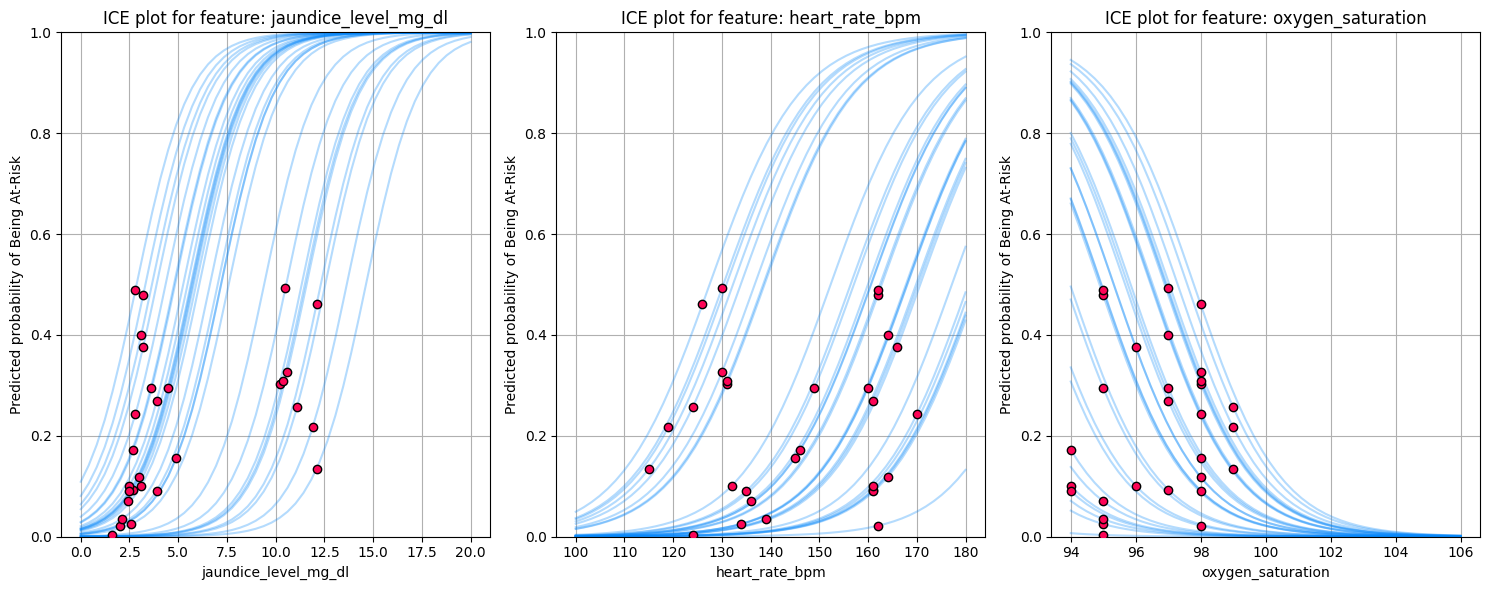

Figure 6. ICE Plots for Jaundice Level (a), Heart Rate (b), and Oxygen Saturation (c)


In [19]:
def plot_ice_multiple_with_dots(
    instances: pd.DataFrame,
    feature: str,
    value_range: np.ndarray | List[float] | List[int],
    ax: matplotlib.axes.Axes,
    preprocessor: BaseEstimator | TransformerMixin,  
    model: BaseEstimator, 
    ylim: Tuple[float, float] = (0, 1),
    alpha: float = 0.3,
) -> None:
    """
    Plot ICE curves for a feature across multiple instances with a dot at each instance's original value.
    """
    for i in range(len(instances)):
        instance = instances.iloc[[i]]
        preds: List[float] = []
        for val in value_range:
            temp: pd.DataFrame = instance.copy()
            temp[feature] = val
            temp_transformed: np.ndarray = preprocessor.transform(temp)
            pred: float = model.predict_proba(temp_transformed)[0, 1]
            preds.append(pred)
        
        # Plot the ICE curve
        ax.plot(value_range, preds, marker=None, alpha=alpha, color='#0888fa')
        
        # Plot a dot at the original feature value
        orig_value = instance[feature].values[0]
        orig_pred = model.predict_proba(preprocessor.transform(instance))[0, 1]
        ax.scatter(orig_value, orig_pred, color='#fd0556', edgecolor="black", zorder=5)
    
    ax.set_xlabel(feature)
    ax.set_ylabel("Predicted probability of Being At-Risk")
    ax.set_title(f"ICE plot for feature: {feature}")
    ax.set_ylim(*ylim)
    ax.grid(True)

# Example usage for misclassified babies
misclassified_babies = X_encoded.iloc[misclassified_indices]  # replace misclassified_mask with your boolean mask
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# What if scenario
features_info = [
    ("jaundice_level_mg_dl", np.linspace(0, 20, 50)),
    ("heart_rate_bpm", np.linspace(100, 180, 50)),
    ("oxygen_saturation", np.linspace(94, 106, 50))
]

for ax, (feature, value_range) in zip(axs, features_info):
    plot_ice_multiple_with_dots(
        misclassified_babies, feature, value_range, ax,
        recreated_preprocessor, old_model['clf']
    )

plt.tight_layout()

image_path = f'figures/0{fig_count}_ice.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)

plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'ICE Plots for Jaundice Level (a), Heart Rate (b), and Oxygen Saturation (c)'
)

fig_count += 1 

Finally, to show a concrete example of how the model overrelied on jaundice, we used LIME to compare two mostly similar babies. We manually reviewed the misclassified cases and identified the most similar babies, Nicole and Tara. Both had comparable heart rates, oxygen saturation levels, and weight with only minor differences in age in days and body temperature. The primary distinction between them was their jaundice level, with Nicole exhibiting a low jaundice level and Tara a high one. The model assigned a higher probability of being at-risk to Tara (29%) and a lower probability to Nicole (9%), indicating that jaundice was the main factor influencing the model’s confidence in these predictions.

In [20]:
# Create the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_encoded.values,
    feature_names=X_encoded.columns.tolist(),
    class_names=['Healthy', 'At Risk'],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    kernel_width=3
)

# Create an anonymous function where given a sample, it predicts using the rf model
def predict_fn(baby):
    baby_df = pd.DataFrame(baby, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict_proba(baby_transformed)

for i in [1341, 57]:
    misclassified_baby = historical_df.loc[i]
    print(f"{misclassified_baby['name']} of index {i} "
          f"was misclassified as healthy on {misclassified_baby['date']}")

    exp = explainer.explain_instance(
        X_encoded.iloc[i].values,   # 1D numpy array
        predict_fn,
        num_features=5
    )

    # Convert to matplotlib figure
    fig = exp.as_pyplot_figure()
    
    # Save figure as high-res PNG
    image_path = f'figures/0{fig_count}_LIME_baby_{i}.png'
    fig.savefig(image_path, bbox_inches='tight', dpi=300)
    plt.close(fig)
    
    exp.show_in_notebook(show_all=True)

print(f'\033[1mFigure {fig_count}\033[0m. '
      'LIME Explanation of Model Predictions for Two Similar Babies'
)

fig_count += 1 

Tara of index 1341 was misclassified as healthy on 2025-03-15


Nicole of index 57 was misclassified as healthy on 2025-08-24


Figure 7. LIME Explanation of Model Predictions for Two Similar Babies


From both the perspectives of the global and local view, we see that jaundice is indeed clearly a strong predictor. However, the model relied on it too heavily, creating blind spots that were risky in practice.

## 4.3 Improve the model of Data Monitors

To improve their model-making process, Data Monitors should consider the following steps:

1. **Assess Class Imbalance Early:** Evaluate the dataset’s class distribution and determine whether resampling strategies are truly necessary, especially when using models like Random Forests that handle moderate imbalance well.
2. **Use Appropriate Evaluation Metrics**: Go beyond accuracy by incorporating metrics like recall, precision, and F1-score, which are more informative in high-stakes contexts such as neonatal care.
3. **Feature-Specific Preprocessing:** Avoid blanket preprocessing methods such as standardizing all features. Instead, consider the statistical properties of each variable—features without a meaningful central tendency, like feeding frequency, urine output, and stool count, should not be standardized.
4. **Cross-validate on Misclassified Cases:** Test models specifically on previously misclassified babies to ensure that changes in preprocessing or model design improve performance for the at-risk population.
5. **Interpretability and Feature Analysis:** Use explainability tools to monitor which features the model relies on, preventing overreliance on a single predictor such as jaundice.

In developing machine learning models, careful attention must be paid to preprocessing and evaluation metrics to ensure both accuracy and safety. In our dataset, the ratio of healthy to at-risk babies was 7:1 (1822 healthy babies to 278 at-risk babies). While this prompted us to experiment with resampling strategies, Random Forests, which we used, handle moderate imbalance effectively. Table 1 below summarizes the models we tested, their resampling strategies, and corresponding F1 scores. We used F1 scores as the evaluation metric to balance precision and recall. High precision is important to minimize false positives, which would otherwise require the medical staff to perform unnecessary monitoring. At the same time, high recall ensures that babies who are truly at risk are correctly identified and receive appropriate attention.


In [42]:
results_df = pd.read_csv('all_classifier_results.csv')
method_order = [
    "Baseline",
    "ROS",
    "RUS",
    "SMOTE",
    "CC-SMOTE",
    "SMOTE-TOMEK",
    "SMOTE-ENN",
    "Class Weight"
]

# Extract the resampling strategy from method
results_df["method"] = results_df["method"].apply(lambda x: " ".join(x.split()[:-1]))

# # Make it categorical based on your desired order
results_df["method"] = pd.Categorical(results_df["method"], categories=method_order, ordered=True)

results_summary_df = results_df.sort_values(by='f1_weighted', ascending=False)[['classifier', 'method', 'f1_weighted']]

display(results_summary_df.style.format({
    'f1_weighted': "{:.2%}",
}))

print(f"\033[1mTable 2\033[0m. Summary of F1-Score of the Models Experimented"
      "across Different Resampling Strategies")

,classifier,method,f1_weighted
0,RandomForest,Baseline,99.76%
1,RandomForest,ROS,99.76%
2,RandomForest,SMOTE,99.29%
3,RandomForest,SMOTE-TOMEK,99.29%
4,RandomForest,Class Weight,99.28%
5,RandomForest,RUS,97.69%
6,SVM,ROS,94.87%
8,SVM,SMOTE,94.19%
9,SVM,SMOTE-TOMEK,94.19%
7,SVM,Class Weight,94.09%


Table 2. Summary of F1-Score of the Models Experimentedacross Different Resampling Strategies


We also found that preprocessing should consider the nature of each feature. For example, feeding frequency, urine output, and stool count follow roughly uniform distributions as shown in Figure 8 and do not have a meaningful central tendency, so standardizing all numerical features, as done by the Data Monitors, is not appropriate. Additionally, evaluation should not rely solely on accuracy. Because we used a Random Forest, there was no need to scale the features.

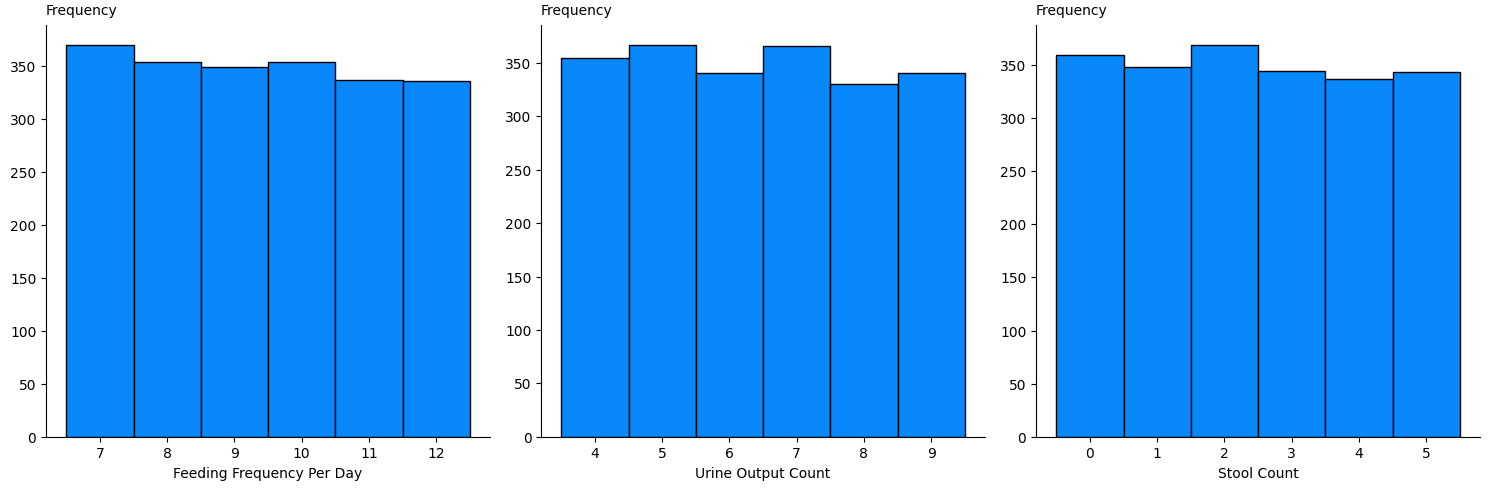

Figure 8. Histograms of Feeding Frequency per Day, Urine Output Count, and Stool Count


In [58]:
features = ['feeding_frequency_per_day', 'urine_output_count', 'stool_count']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axs, features):
    # Get min and max for bin edges
    data = historical_df[feature].dropna()
    bins = range(int(data.min()), int(data.max()) + 2)  # +2 to include the last value
    ax.hist(data, bins=bins, color='#0888fa', edgecolor='black', align='left')
    
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency', rotation=0, ha='left')
    ax.yaxis.set_label_coords(0, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

image_path = f'figures/0{fig_count}_histograms_uniform.png'
plt.savefig(image_path, bbox_inches='tight', dpi=300)

plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Histograms of Feeding Frequency per Day, Urine Output Count, and Stool Count'
)

fig_count += 1


Overall, the baseline Random Forest achieved the highest average F1 score (0.9976), outperforming all resampling methods such as SMOTE, SMOTE-TOMEK, and ROS. This indicates that the dataset’s natural class distribution was sufficient, and resampling did not improve performance. Resampling is typically used to address severe class imbalance, but in this case, it likely introduced noise and redundancy, reducing precision. Random Forest naturally handles moderate imbalance through ensemble averaging and bootstrap sampling, allowing it to generalize well without synthetic data. 

Once the model was trained, we performed cross-validation to assess its generalization performance. Using the validation set, we computed global SHAP values to evaluate how the model prioritizes features on unseen data. As seen in Figure 9,  the level of jaundice remains the most influential feature, indicating that the model continues to rely heavily on it even when applied to new data.


In [5]:
# Define columns
numerical_cols = [
    'age_days',
    'feeding_frequency_per_day',
    'urine_output_count',
    'stool_count',
    'gestational_age_weeks',
    'weight_kg',
    'length_cm',
    'head_circumference_cm',
    'temperature_c',
    'heart_rate_bpm',
    'respiratory_rate_bpm',
    'oxygen_saturation',
    'jaundice_level_mg_dl',
]
categorical_cols = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']

# Feature and target separation
X = historical_df.drop(columns=['risk_level']).copy()
#y = historical_df['risk_level'].copy().map({'Healthy': 0, 'At Risk': 1})  # keep as integers
y = historical_df['risk_level'].copy()

# Train–validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


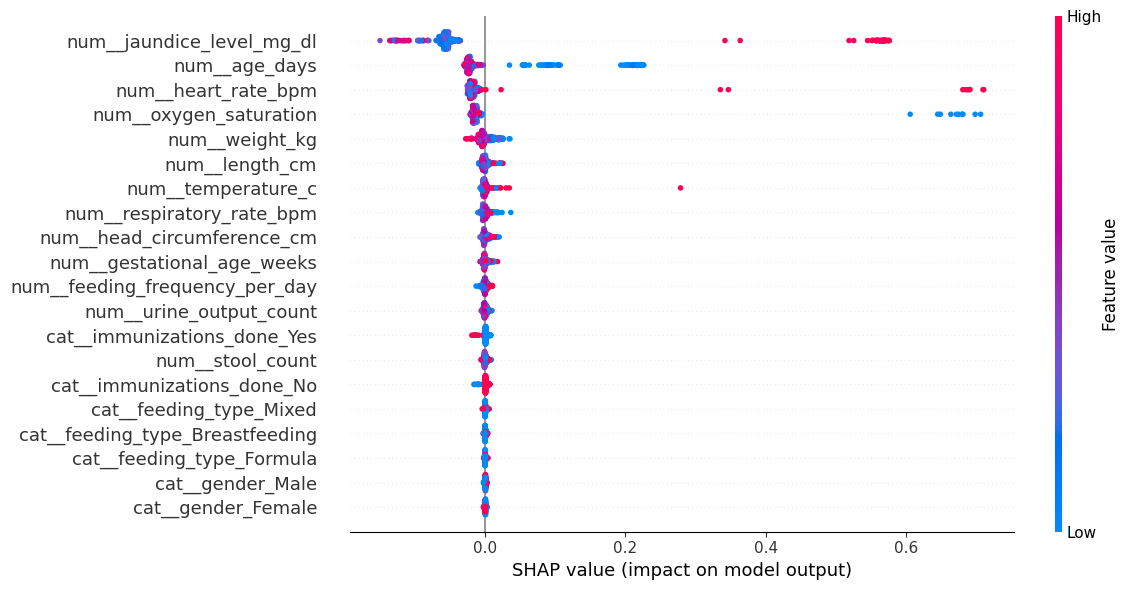

Figure 9. SHAP Summary: Key Drivers of At-Risk Predictions in Newborns for Data Monitors' Model


In [16]:
# Instantiate WhiteBox model
wb = WhiteBox(random_state=42)

# Fit model with preprocessing (WhiteBox handles label encoding internally)
wb.fit(X_train, y_train, numerical_cols=numerical_cols, categorical_cols=categorical_cols)

# Make predictions on validation se
y_pred = wb.predict(X_val)  # returns original string labels

# Encode
y_val_encoded = y_val.map({'Healthy': 0, 'At Risk': 1})

# Compute SHAP values on the PROCESSED data
shap_values = wb.treeshap(X_val)

# Select the class index you want to explain (1 = "At Risk")
class_idx = 1

# Create the SHAP summary plot
plt.figure()
shap.summary_plot(
    shap_values[:, :, class_idx],
    wb.preprocessor.transform(X_val),
    show=False,  # Prevent it from displaying immediately,
    plot_size=(12, 6) 
)

# Save the plot as a PNG image
fig_count = 9
image_path = f"figures/0{fig_count}_shap_summary_new_model.png"
plt.savefig(image_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print(f'\033[1mFigure {fig_count}\033[0m. '
      "SHAP Summary: Key Drivers of At-Risk Predictions "
      "in Newborns for Data Monitors' Model"
)

fig_count += 1 



We next examined how important jaundice is. As shown in the permutation importances in Figure 10, the model is actually heavily reliant on this feature. This represents a key limitation of our proof-of-concept model since even the random forest model continues to prioritize jaundice as a primary indicator due to its strong power between differentiating healthy and at-risk infants. Thus, this limitation shows a carefeel the need for feature consideration and potential model adjustments to ensure a more balanced assessment of risk factors in neonatal care.

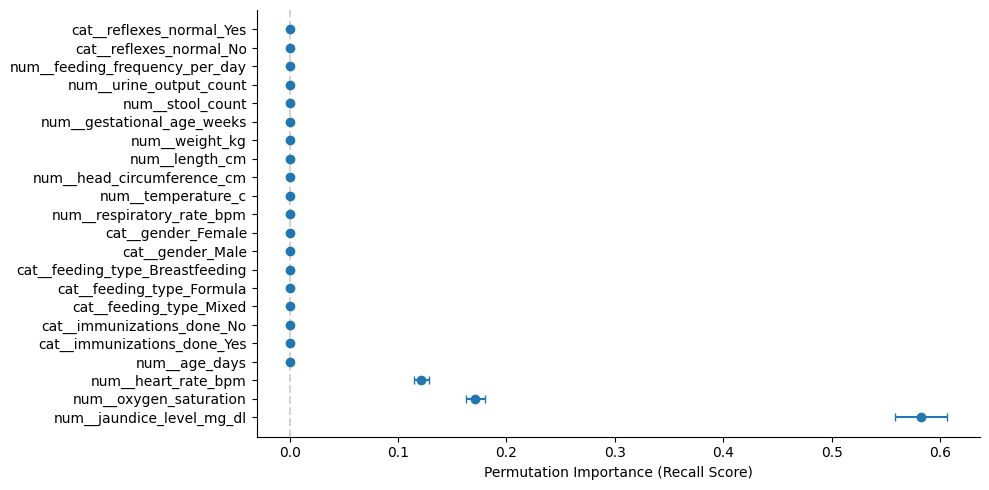

Figure 10. Permutation Importance


In [17]:
X_preprocessed_val = wb.preprocessor.transform(X_val)

perm_imp = permutation_importance(
    wb._model_,
    X_preprocessed_val,
    y_val_encoded,
    scoring="recall",
    random_state=42,
    n_repeats=5
)

# Use raw column names (not preprocessed ones) for interpretability
FEATURE_NAMES = np.array(X_preprocessed_val.columns)

# Sort by importance
idx_order = np.argsort(-perm_imp.importances_mean)
ordered_means = perm_imp.importances_mean[idx_order]
ordered_stds = perm_imp.importances_std[idx_order]
ordered_labels = FEATURE_NAMES[idx_order]

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=ordered_means,
    y=ordered_labels,
    xerr=ordered_stds,
    fmt="o",
    capsize=3
)
plt.xlabel("Permutation Importance (Recall Score)")
plt.axvline(0, linestyle="--", c="lightgray")
#plt.title("Permutation Importance (Using Model Features Only)")
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
image_path = f"figures/{fig_count}_permuation_importance_new_model.png"
plt.savefig(image_path, bbox_inches='tight', dpi=300)
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Permutation Importance'
)

fig_count += 1

To support clinical decision-making, we complemented these global interpretability analyses with local explainable tools, which provide individualized insights for each prediction. We implemented the ```explain_why``` method to clarify the features driving a particular prediction. We show an example below of how it would like. This would tell that the jaundice level was bringing the prediction to be a more healthy baby and the such.


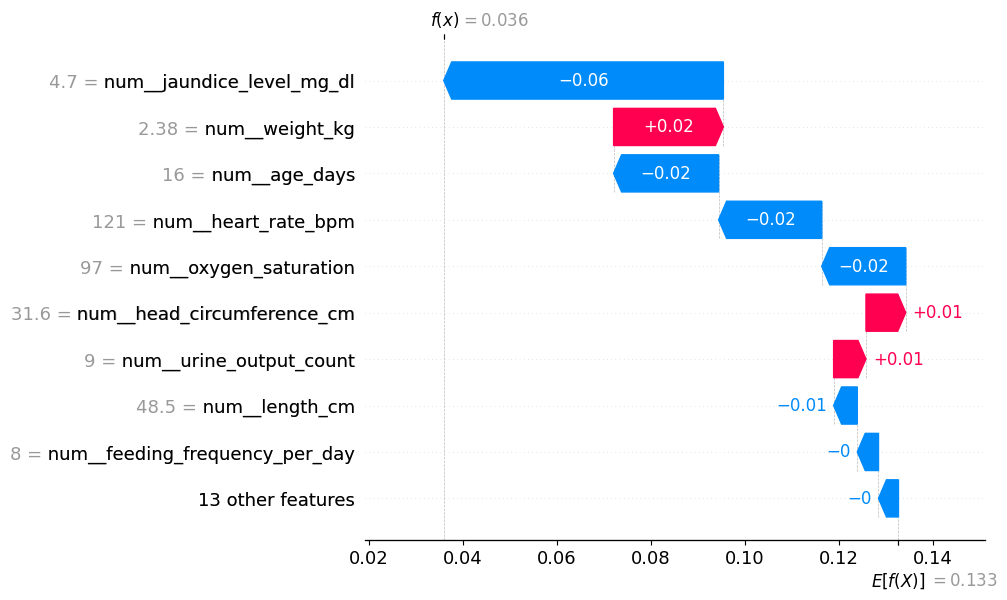

Figure 11. Example of the explain_why Method


In [18]:
wb.explain_prediction(X_val.iloc[[0]])

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Example of the explain_why Method'
)

fig_count += 1

___

# **V. AI Accountability and Governance Framework** 

AI accountability and governance is the set of rules, roles, and oversight mechanisms that ensure AI systems are used safely, transparently, and responsibly, especially in high-stakes contexts. It is crucial because it clarifies who is responsible when errors occur, such as a baby being misclassified, allowing for timely corrective actions and maintaining trust in clinical decision-making.

In the new accountability framework, St. James Hospital and Data Monitors have distinct yet interconnected responsibilities that together ensure patient safety and model reliability. St. James Hospital is primarily responsible for the integrity of the data and its clinical use. This includes ensuring data input quality by accurately recording medical records and sensor readings, performing medical validation to confirm the model’s outputs are clinically sound, and maintaining decision oversight, ensuring that all risk classifications inform patient care only after clinician review. The hospital preserves the human in the loop, maintaining ethical, accurate, and timely assessment of all model-driven outputs.

Data Monitors oversee the technical performance of the AI system. Their responsibilities include model maintenance, drift detection, and performance auditing. They regularly monitor model behavior, track shifts in data distributions, update data pipelines when necessary, and ensure that the model operates transparently for medical staff. By doing so, Data Monitors provide the hospital with a reliable tool while enabling St. James to uphold clinical governance.

When a misclassification occurs, accountability is determined through a stepwise process as shown in the Figure 9. First, investigators check the data: if the error is caused by incomplete or inaccurate data entry, such as missing vitals or transcription errors, St. James Hospital is held responsible. If the data is correct, the next step examines the model: if the misclassification results from model bias, feature drift, or outdated pipelines, responsibility shifts to Data Monitors. If neither data nor model issues are present, the investigation reviews clinical actions: if a clinician disregards or misinterprets the model’s alerts, the error is classified as a human process violation, triggering procedural review. This if-then flow ensures that accountability is systematic, evidence-based, and clearly traceable.

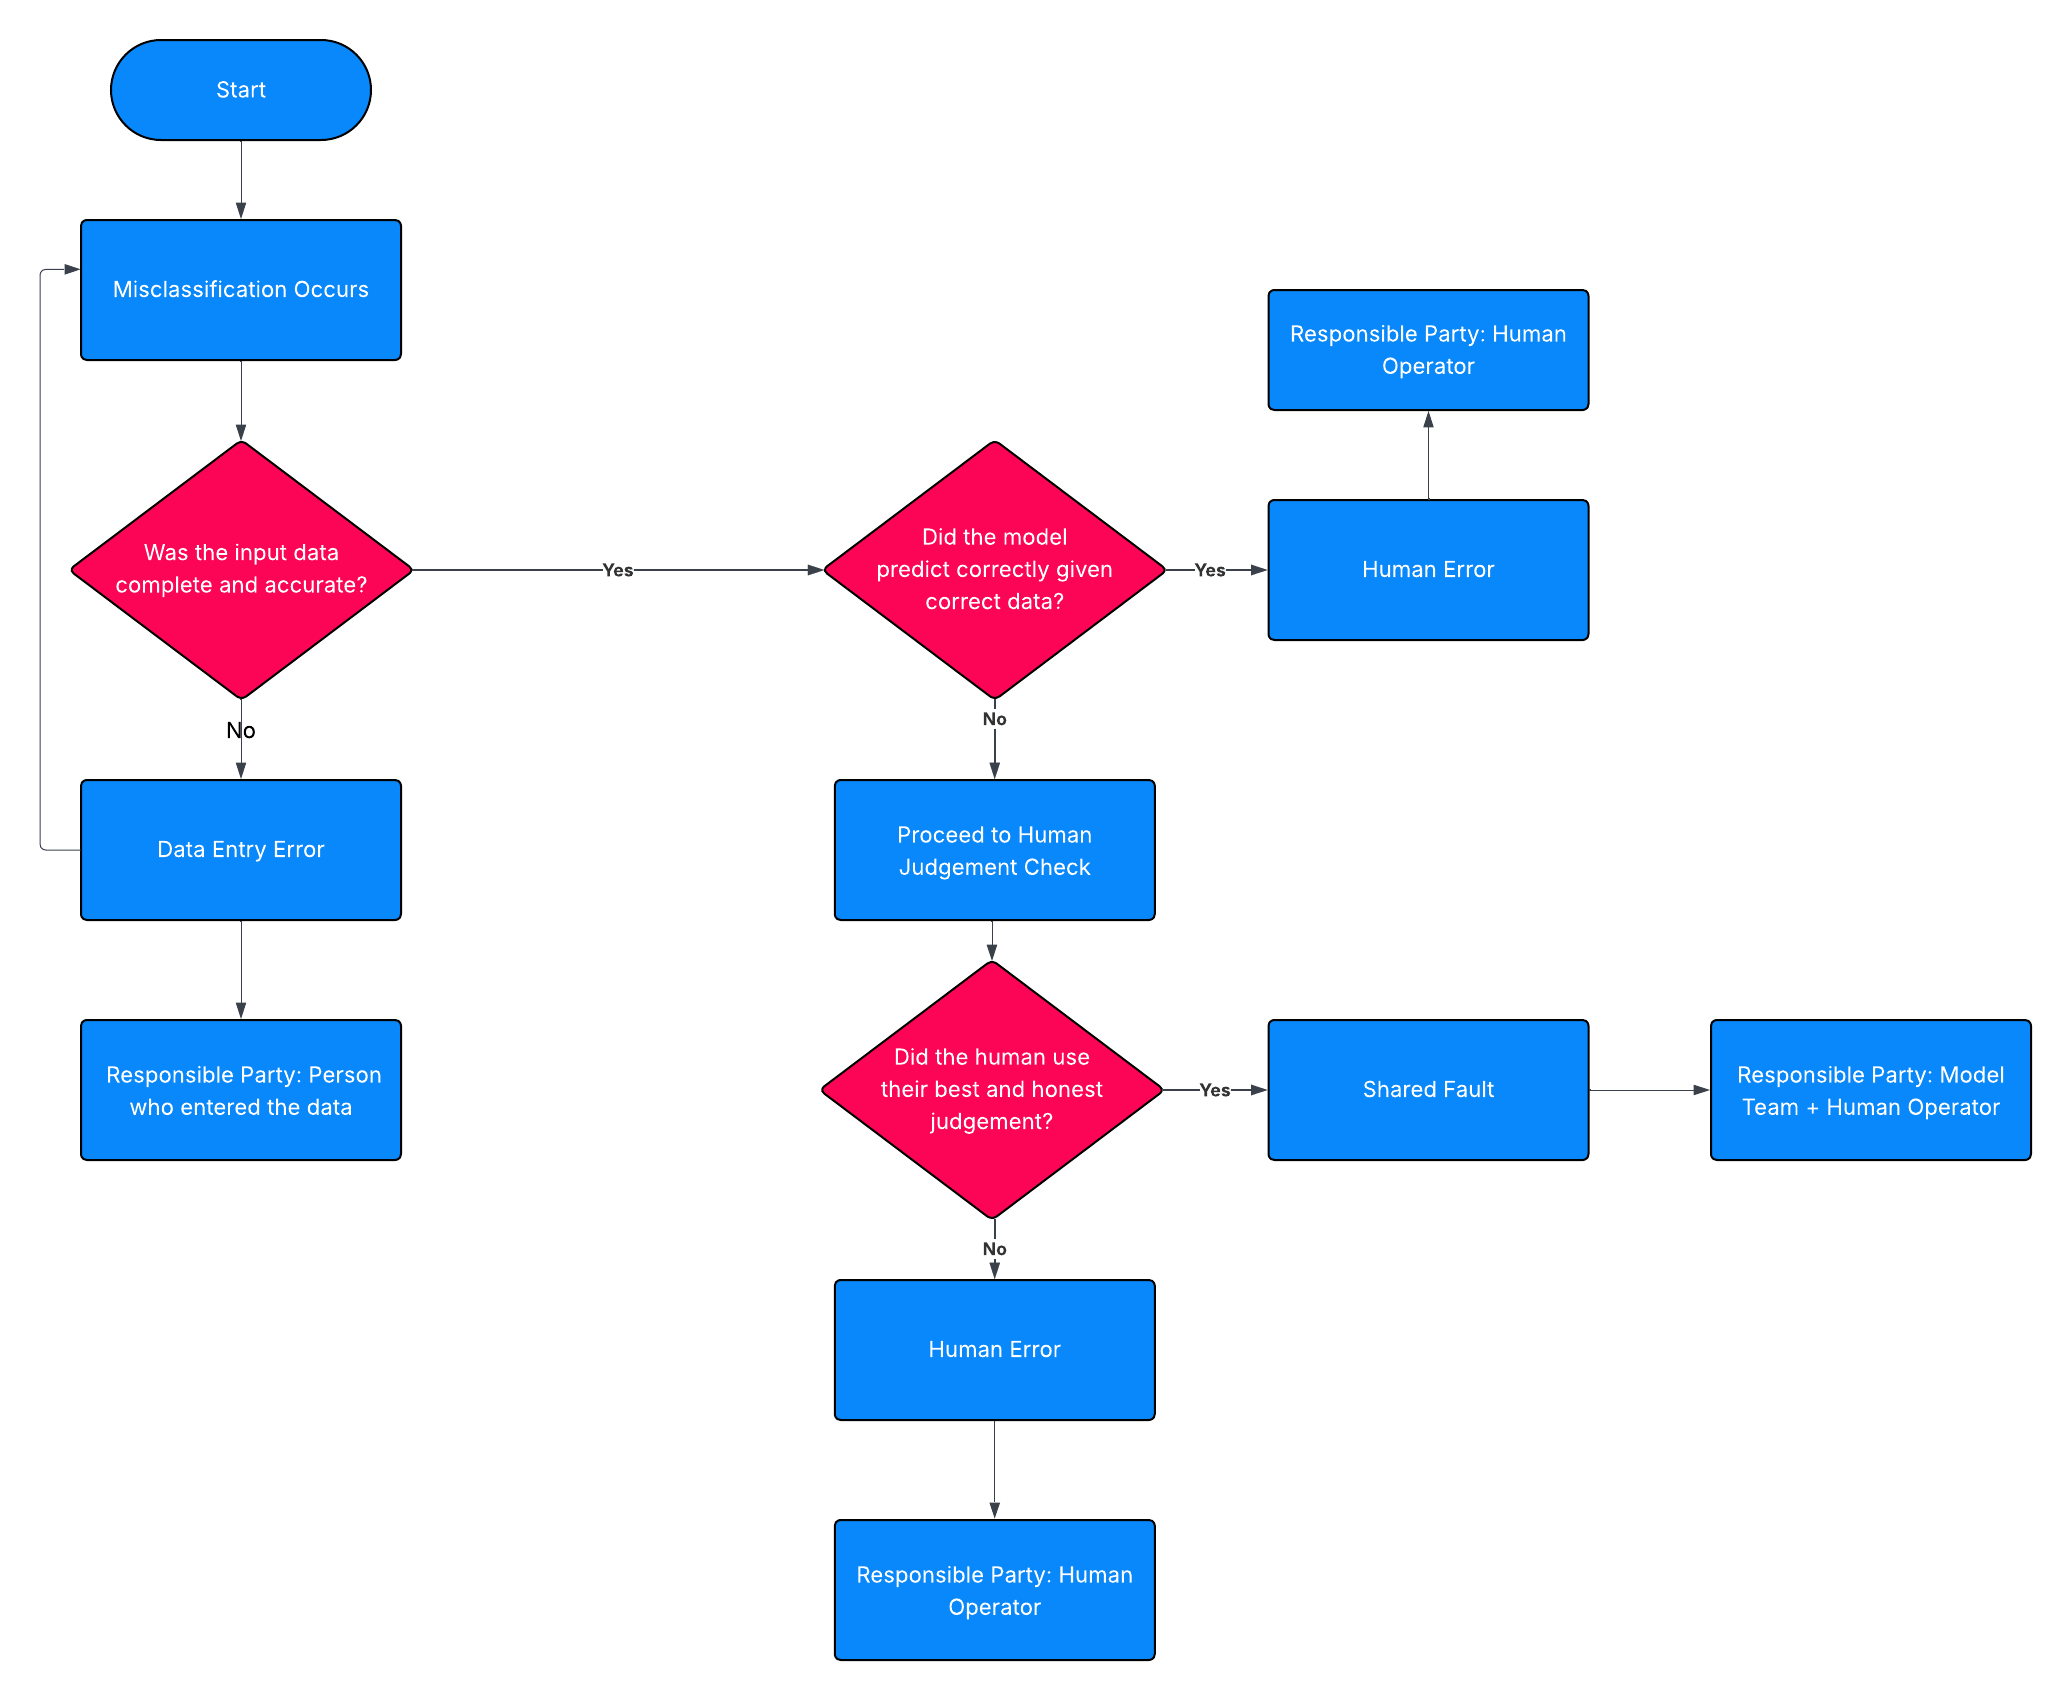
Figure 11. Proposed Process for Determining Responsibility

To ensure continuous compliance and performance, St. James Hospital must implement structured monitoring requirements. These include weekly drift detection reports on feature importance and data stability, monthly performance audits tracking metrics such as F1-score, recall, and false-negative rates, and quarterly joint governance reviews where both organizations validate audit logs and update accountability documentation. Additionally, Data Monitors should provide real-time dashboards of model metrics and bias indicators, allowing the hospital to independently verify ongoing compliance. Together, these practices create a continuous feedback loop that safeguards patient care, detects model degradation early, and maintains adherence to technical and regulatory standards.


# **VII. Conclusion and Recommendations** 

6.1 Recommendations

Our proposed framework offers a robust solution for improving newborn monitoring, and further enhancing it can make the process even more reliable and trustworthy. While our proof-of-concept model metrics outperform those of Data Monitors, we observed that the predictions tend to over-rely on jaundice levels. However, this can be mitigated through the proposed human-in-the-loop checks, which empower the medical staff to validate or override predictions. 

6.2 Conclusion

The failures at St. James Hospital’s OB-GYN facility reveal flaws in both the monitoring process and the deployed model. The hospital overrelied on a machine learning system without sufficient oversight, while Data Monitors provided a model that overfit to jaundice and underweighted other crucial features, causing misclassifications. Explainable AI tools such as SHAP, permutation importance, and LIME identified these blind spots and guided improvements. By empowering medical staff with informed decisions through TreeExplainer and using a Random Forest to capture nonlinear patterns, we showed that transparency and human oversight are essential for safe, reliable AI in healthcare.
Our framework also integrates an AI Accountability and Governance structure in case errors do occur. Responsibilities are clearly defined. For example, St. James Hospital ensures data integrity, clinical validation, and human-in-the-loop oversight, while Data Monitors maintain model performance and transparency. Misclassifications are traced systematically and supported by ongoing audits and joint governance. This approach ensures safe, dependable AI, reduces staff workload, and maintains trust in clinical decision-making.


___

# **References**
[1] Hall V, et al. Hemolytic Disease of the Fetus and Newborn. [Updated 2025 Jan 22]. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; 2025 Jan-. Available from: https://www.ncbi.nlm.nih.gov/books/NBK557423/


---

# **Supplementary**
